Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, errno
import sys

#Settings
BASE_DIR = 'test_poissonPG_IPACT_pred_ridge'
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 20
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.01, 0.05, 0.1, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [20]
parameters = [{'w':12, 'p':1}]
#parameters = [{'w':5, 'p':3}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000', '3072000', '3840000']

for size in PKT_SIZES:
    IPACT[size] = {}

In [12]:
for exp in exponents:
    for payload_size in PKT_SIZES:
        aux = []
        for seed in seeds:
            df_tmp = pd.read_csv("{}/{}km/{}/csv/delay/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w{}-p{}-s{}-delay.csv".format(BASE_DIR, DISTANCE, payload_size, DBA_ALG, DISTANCE,
                                                                                                    NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                    TRAFFIC, exp, payload_size, 25, 1, seed))
            df_tmp_ipact_basic = pd.read_csv("test_poissonPG_IPACT/{}km/{}/csv/delay/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-delay.csv".format(DISTANCE, payload_size, DISTANCE,
                                                                                                                                        NUMBER_OF_ONUs, NUMBER_OF_OLTs,
                                                                                                                                        TRAFFIC, exp, payload_size, seed))
            pred_grants = df_tmp
            normal_grants = df_tmp_ipact_basic
            delay_division = pred_grants['Mean']/normal_grants['Mean']
            aux.append(delay_division)
        IPACT[payload_size][exp] = np.mean(aux)
visual_df = pd.DataFrame(IPACT)

In [13]:
visual_df

,768000,1536000,3072000,3840000
0.01,1.000000,1.000000,1.000000,1.000000
0.05,51.120028,36.959380,22.023331,18.473032
0.10,45.772561,28.077150,13.979833,8.465150
0.20,19.408445,9.034081,0.764189,0.533835
0.30,9.872897,1.657935,0.482933,0.564387
0.40,4.281355,0.528641,0.580035,0.619807
0.50,1.092163,0.436814,0.610242,0.648242
0.60,0.581573,0.486906,0.623485,0.662612
0.70,0.456242,0.521116,0.636111,0.667843
0.80,0.413757,0.560088,0.653069,0.676652


Abertura de figura e edição de título.

[0.23584598 0.0366032  0.05787891 0.09121095 0.13170982 0.169838
 0.22331086 0.27848406 0.30582223 0.36254423 0.4555759  0.48735061]
[0.23584598 0.0366032  0.05787891 0.09121095 0.13170982 0.169838
 0.22331086 0.27848406 0.30582223 0.36254423 0.4555759  0.48735061]
[0.25578097 0.04254475 0.07286498 0.11224081 0.15479945 0.23434152
 0.30093228 0.41578028 0.49102932 0.60936556 0.71803643 0.80470923]
[0.25578097 0.04254475 0.07286498 0.11224081 0.15479945 0.23434152
 0.30093228 0.41578028 0.49102932 0.60936556 0.71803643 0.80470923]
[0.32196222 0.07041064 0.09499915 0.17306004 0.27368891 0.46405324
 0.65286792 0.9179611  1.17252785 1.40473325 1.61830315 1.76803988]
[0.32196222 0.07041064 0.09499915 0.17306004 0.27368891 0.46405324
 0.65286792 0.9179611  1.17252785 1.40473325 1.61830315 1.76803988]
[0.35528587 0.06833637 0.11416136 0.19893123 0.35178017 0.60705206
 0.90867368 1.18735882 1.47694306 1.7304177  1.77768539 1.87208474]
[0.35528587 0.06833637 0.11416136 0.19893123 0.35178017 0.6

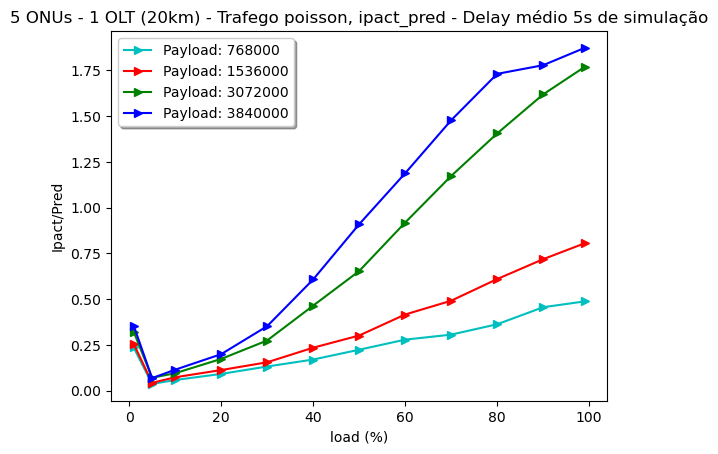

In [ ]:
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Delay médio 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Ipact/Pred")
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")


i = 0
for size in PKT_SIZES:
    aux_label = "Payload: {}".format(size)
    array_aux = np.array(visual_df[size])
    print(array_aux)
    #plt.errorbar(loads, array_aux[:,0], array_aux[:,1], color=colors[j], linestyle='None')
    plt.plot(loads, array_aux, '->', color=colors[i], label=aux_label)
    print(array_aux)
    i += 1

#array_aux = np.array(ipact_basic_df)
#aux_label = 'Ipact Básico'
#plt.plot(loads, array_aux[0], '->', color='c', label=aux_label)

#plt.axhline(y=ipact_basic_df[0], color='r', li1nestyle='-', label='Ipact Básico')

plt.legend(loc='best', shadow=True)
plt.show()